# **Install and Import Libraries**

In [10]:
# Run once if seaborn is not installed
# %pip install seaborn matplotlib --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global style settings — applies to all charts
plt.rcParams['font.family']  = 'DejaVu Sans'
plt.rcParams['figure.dpi']   = 130
sns.set_style('whitegrid')

print('Libraries ready!')

Libraries ready!


# **Load Data**

In [3]:
INPUT_FILE = 'Gamage_Recruiters_Sentiment_Results.xlsx'

df = pd.read_excel(INPUT_FILE, sheet_name='Sentiment_Results')
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Colour map — used consistently across ALL charts
COLORS = {
    'Positive' : '#2ecc71',   # green
    'Neutral'  : '#f39c12',   # orange
    'Negative' : '#e74c3c'    # red
}

print(f'Rows loaded: {len(df)}')
print(df['final_sentiment'].value_counts())

Rows loaded: 21
final_sentiment
Positive    19
Neutral      2
Name: count, dtype: int64


# **Chart 1: Pie Chart — Overall Sentiment Distribution**

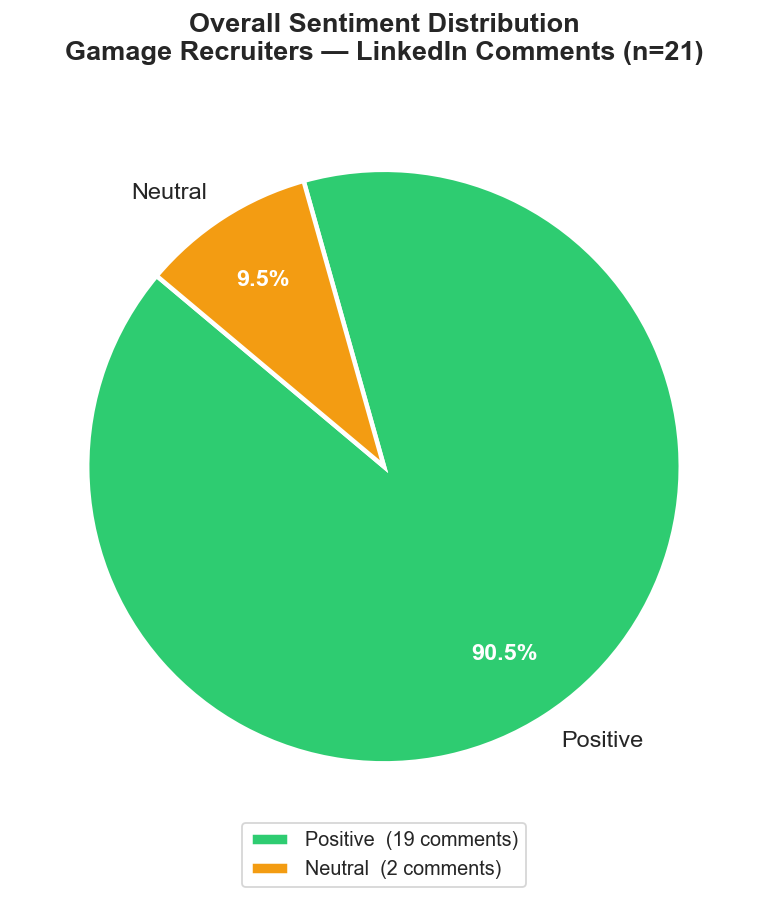

Chart 1 saved: charts/chart1_pie_overall_sentiment.png


In [4]:
counts = df['final_sentiment'].value_counts()
labels = counts.index.tolist()
sizes  = counts.values.tolist()
colors = [COLORS[l] for l in labels]

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels      = labels,
    colors      = colors,
    autopct     = '%1.1f%%',
    startangle  = 140,
    pctdistance = 0.75,
    wedgeprops  = dict(edgecolor='white', linewidth=2.5),
    textprops   = dict(fontsize=13)
)

# Make percentage text bold and white
for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax.set_title(
    'Overall Sentiment Distribution\nGamage Recruiters — LinkedIn Comments (n=21)',
    fontsize=15, fontweight='bold', pad=20
)

# Add count labels as legend
legend_labels = [f'{l}  ({c} comments)' for l, c in zip(labels, sizes)]
ax.legend(wedges, legend_labels, loc='lower center',
          bbox_to_anchor=(0.5, -0.08), fontsize=11)

plt.tight_layout()
plt.savefig('charts/chart1_pie_overall_sentiment.png', bbox_inches='tight')
plt.show()
print('Chart 1 saved: charts/chart1_pie_overall_sentiment.png')

# **Chart 2: Bar Chart — Sentiment by Post Type**

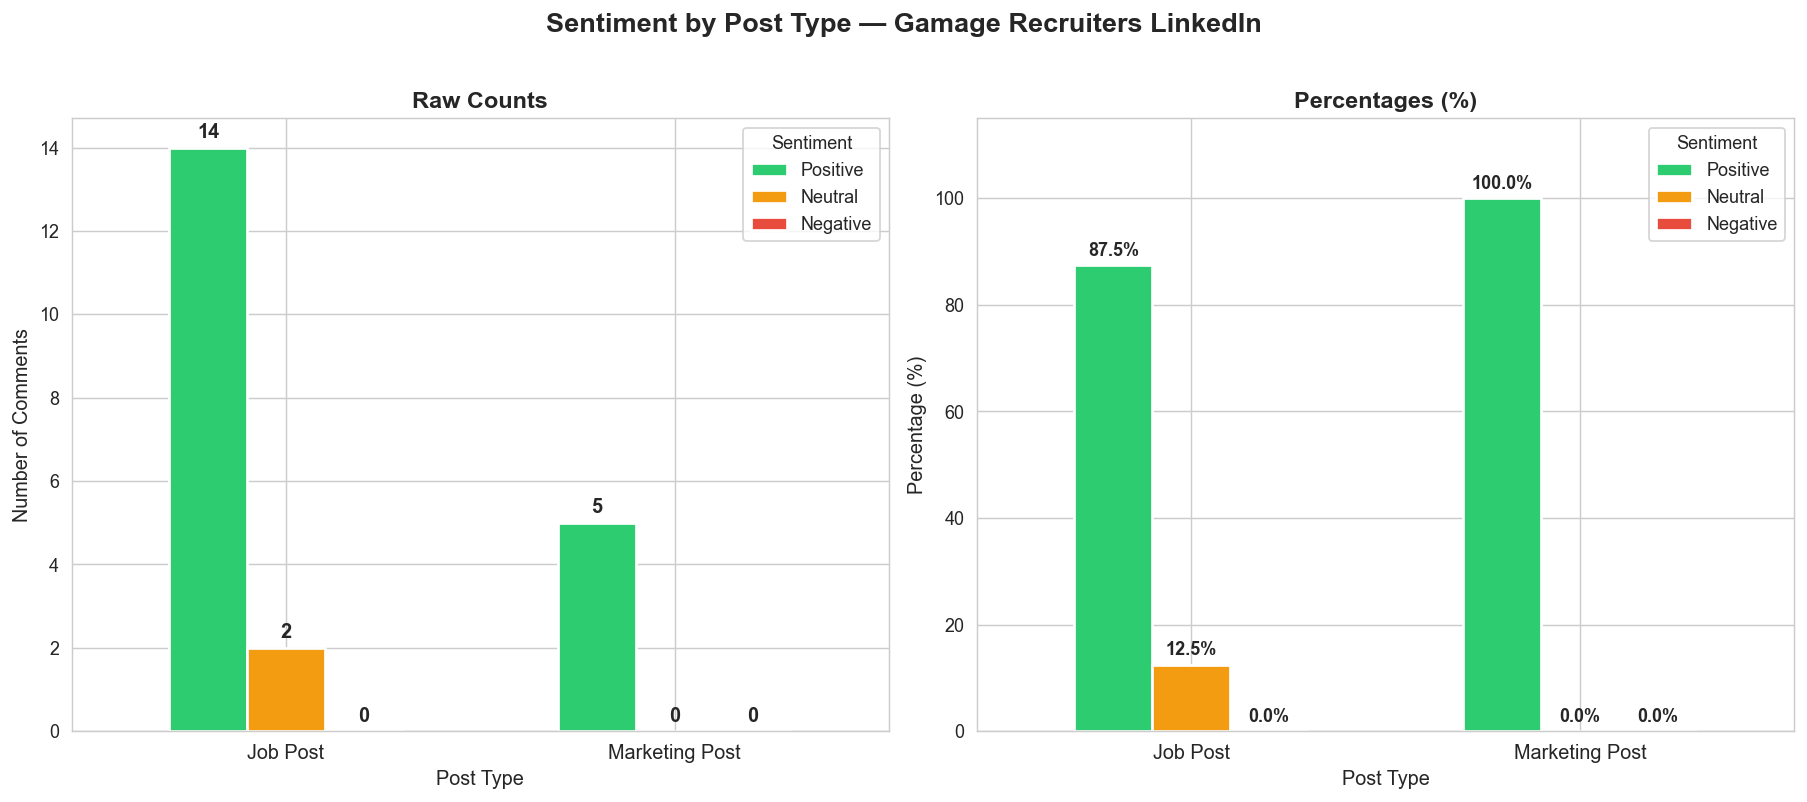

Chart 2 saved: charts/chart2_bar_sentiment_by_posttype.png


In [5]:
# Build grouped data
by_type = df.groupby(
    ['post_type', 'final_sentiment']
).size().unstack(fill_value=0)

# Make sure both sentiment columns exist
for col in ['Positive', 'Neutral', 'Negative']:
    if col not in by_type.columns:
        by_type[col] = 0

by_type = by_type[['Positive', 'Neutral', 'Negative']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Sentiment by Post Type — Gamage Recruiters LinkedIn',
    fontsize=15, fontweight='bold', y=1.02
)

# ── Left chart: Raw counts ──────────────────────────────────
by_type.plot(
    kind   = 'bar',
    ax     = axes[0],
    color  = [COLORS[c] for c in by_type.columns],
    edgecolor = 'white',
    linewidth = 1.5,
    width  = 0.6
)
axes[0].set_title('Raw Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Post Type', fontsize=11)
axes[0].set_ylabel('Number of Comments', fontsize=11)
axes[0].set_xticklabels(by_type.index, rotation=0, fontsize=11)
axes[0].legend(title='Sentiment', fontsize=10)

# Add value labels on bars
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=11,
                      fontweight='bold', padding=3)

# ── Right chart: Percentages ────────────────────────────────
by_type_pct = by_type.div(by_type.sum(axis=1), axis=0) * 100

by_type_pct.plot(
    kind      = 'bar',
    ax        = axes[1],
    color     = [COLORS[c] for c in by_type_pct.columns],
    edgecolor = 'white',
    linewidth = 1.5,
    width     = 0.6
)
axes[1].set_title('Percentages (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Post Type', fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].set_ylim(0, 115)
axes[1].set_xticklabels(by_type_pct.index, rotation=0, fontsize=11)
axes[1].legend(title='Sentiment', fontsize=10)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%',
                      fontsize=10, fontweight='bold', padding=3)

plt.tight_layout()
plt.savefig('charts/chart2_bar_sentiment_by_posttype.png', bbox_inches='tight')
plt.show()
print('Chart 2 saved: charts/chart2_bar_sentiment_by_posttype.png')

# **Chart 3: Horizontal Bar Chart — VADER Scores Per Comment**

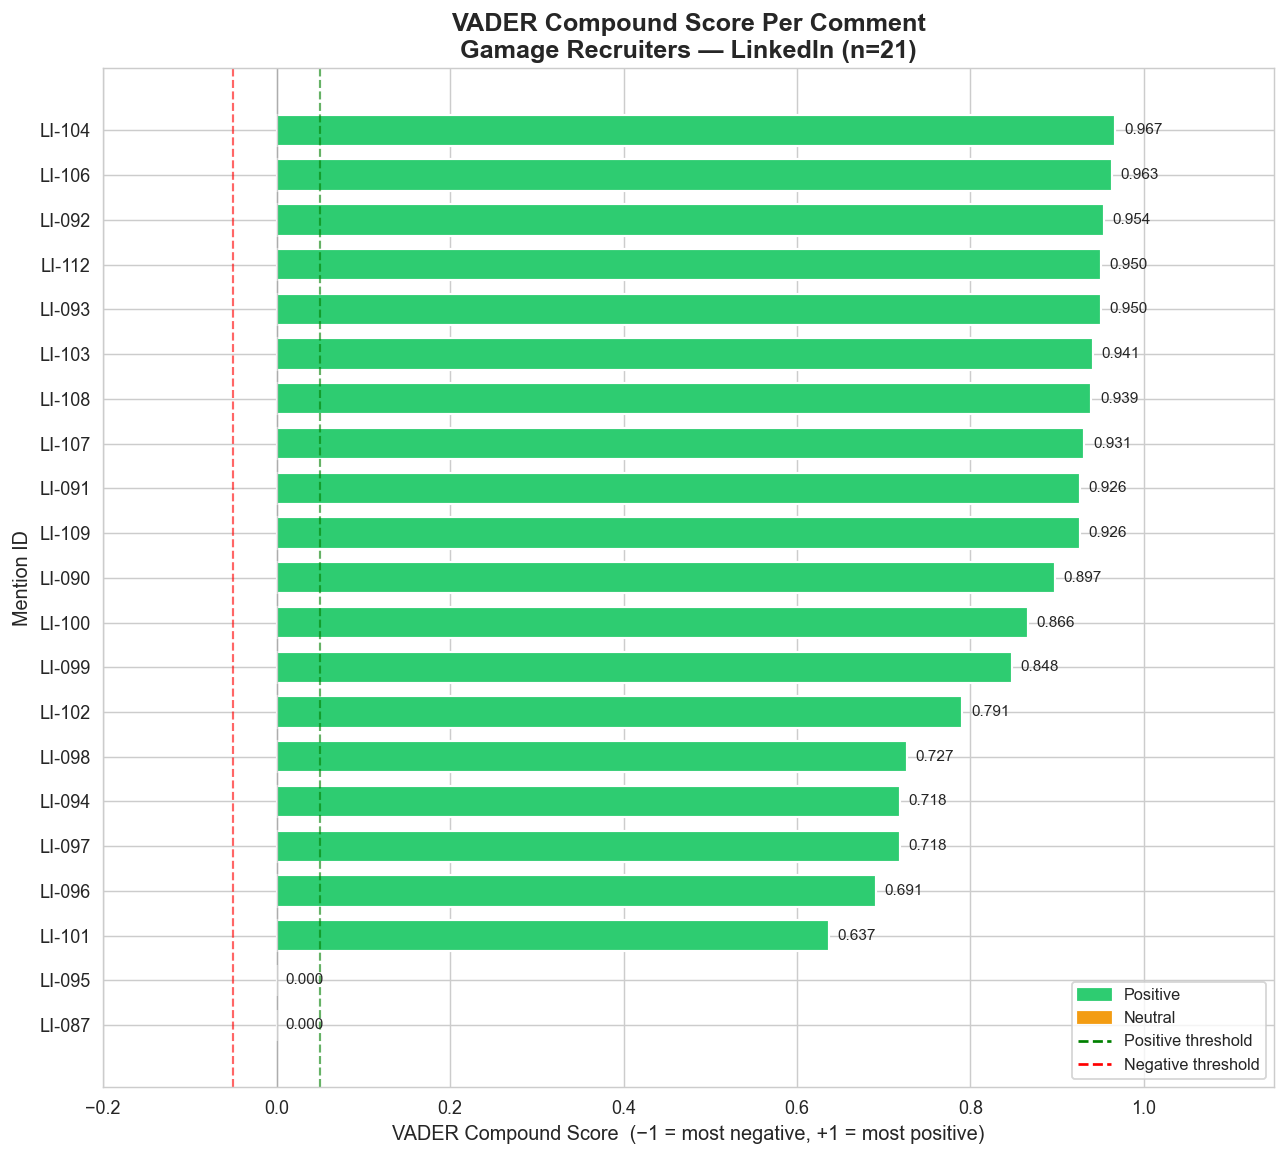

Chart 3 saved: charts/chart3_hbar_vader_scores.png


In [6]:
# Sort by VADER score
df_sorted = df.sort_values('vader_compound', ascending=True).copy()
bar_colors = [COLORS[s] for s in df_sorted['final_sentiment']]

fig, ax = plt.subplots(figsize=(10, 9))

bars = ax.barh(
    df_sorted['mention_id'],
    df_sorted['vader_compound'],
    color     = bar_colors,
    edgecolor = 'white',
    linewidth = 1.2,
    height    = 0.7
)

# Reference line at neutral threshold
ax.axvline(x=0.05,  color='green', linestyle='--',
           linewidth=1.2, alpha=0.6, label='Positive threshold (0.05)')
ax.axvline(x=-0.05, color='red',   linestyle='--',
           linewidth=1.2, alpha=0.6, label='Negative threshold (-0.05)')
ax.axvline(x=0,     color='gray',  linestyle='-',
           linewidth=0.8, alpha=0.4)

# Value labels
for bar, val in zip(bars, df_sorted['vader_compound']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8.5)

# Legend for sentiment colors
legend_handles = [
    mpatches.Patch(color=COLORS['Positive'], label='Positive'),
    mpatches.Patch(color=COLORS['Neutral'],  label='Neutral'),
]
ax.legend(handles=legend_handles + [
    plt.Line2D([0],[0], color='green', linestyle='--', label='Positive threshold'),
    plt.Line2D([0],[0], color='red',   linestyle='--', label='Negative threshold'),
], fontsize=9, loc='lower right')

ax.set_title(
    'VADER Compound Score Per Comment\nGamage Recruiters — LinkedIn (n=21)',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('VADER Compound Score  (−1 = most negative, +1 = most positive)',
              fontsize=11)
ax.set_ylabel('Mention ID', fontsize=11)
ax.set_xlim(-0.2, 1.15)

plt.tight_layout()
plt.savefig('charts/chart3_hbar_vader_scores.png', bbox_inches='tight')
plt.show()
print('Chart 3 saved: charts/chart3_hbar_vader_scores.png')

# **Chart 4: Stacked Bar — Meaningful vs Low Quality Comments**

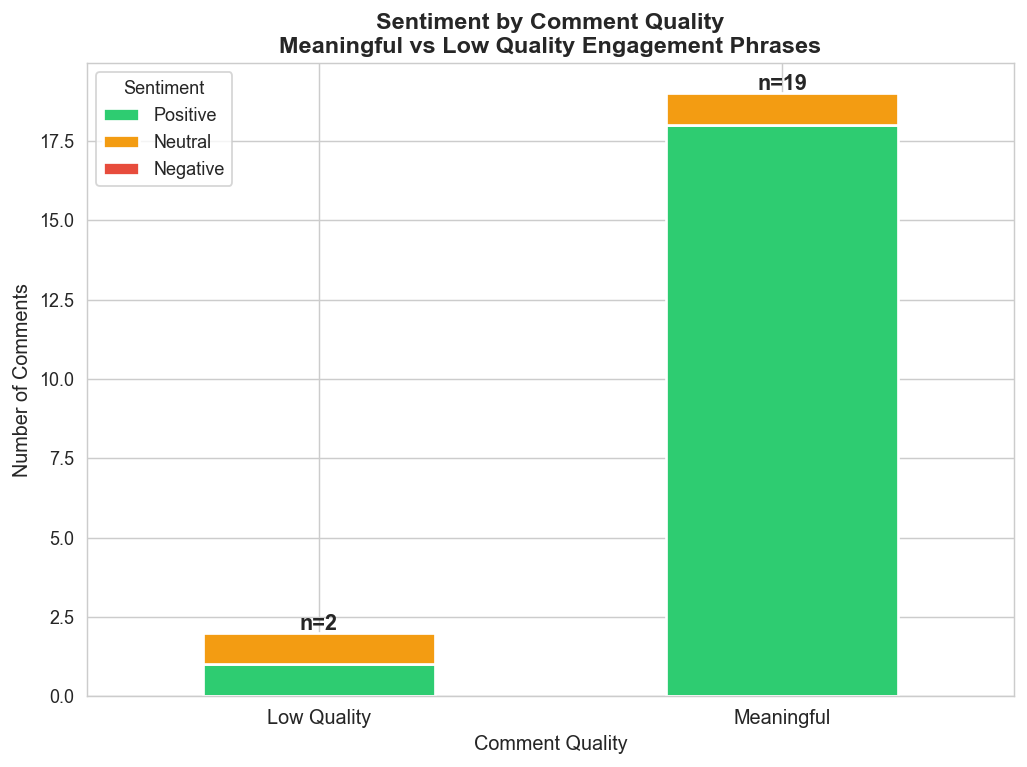

Chart 4 saved: charts/chart4_stacked_quality.png


In [7]:
quality_map  = {True: 'Meaningful', False: 'Low Quality'}
df['quality'] = df['is_meaningful'].map(quality_map)

quality_pivot = df.groupby(
    ['quality', 'final_sentiment']
).size().unstack(fill_value=0)

for col in ['Positive', 'Neutral', 'Negative']:
    if col not in quality_pivot.columns:
        quality_pivot[col] = 0

quality_pivot = quality_pivot[['Positive', 'Neutral', 'Negative']]

fig, ax = plt.subplots(figsize=(8, 6))

quality_pivot.plot(
    kind      = 'bar',
    stacked   = True,
    ax        = ax,
    color     = [COLORS[c] for c in quality_pivot.columns],
    edgecolor = 'white',
    linewidth = 1.5,
    width     = 0.5
)

ax.set_title(
    'Sentiment by Comment Quality\nMeaningful vs Low Quality Engagement Phrases',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Comment Quality', fontsize=11)
ax.set_ylabel('Number of Comments', fontsize=11)
ax.set_xticklabels(quality_pivot.index, rotation=0, fontsize=11)
ax.legend(title='Sentiment', fontsize=10)

# Add total count labels on top of each bar
totals = quality_pivot.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(i, total + 0.1, f'n={int(total)}',
            ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('charts/chart4_stacked_quality.png', bbox_inches='tight')
plt.show()
print('Chart 4 saved: charts/chart4_stacked_quality.png')

# **Chart 5: Scatter Plot — VADER vs TextBlob Score Agreement**

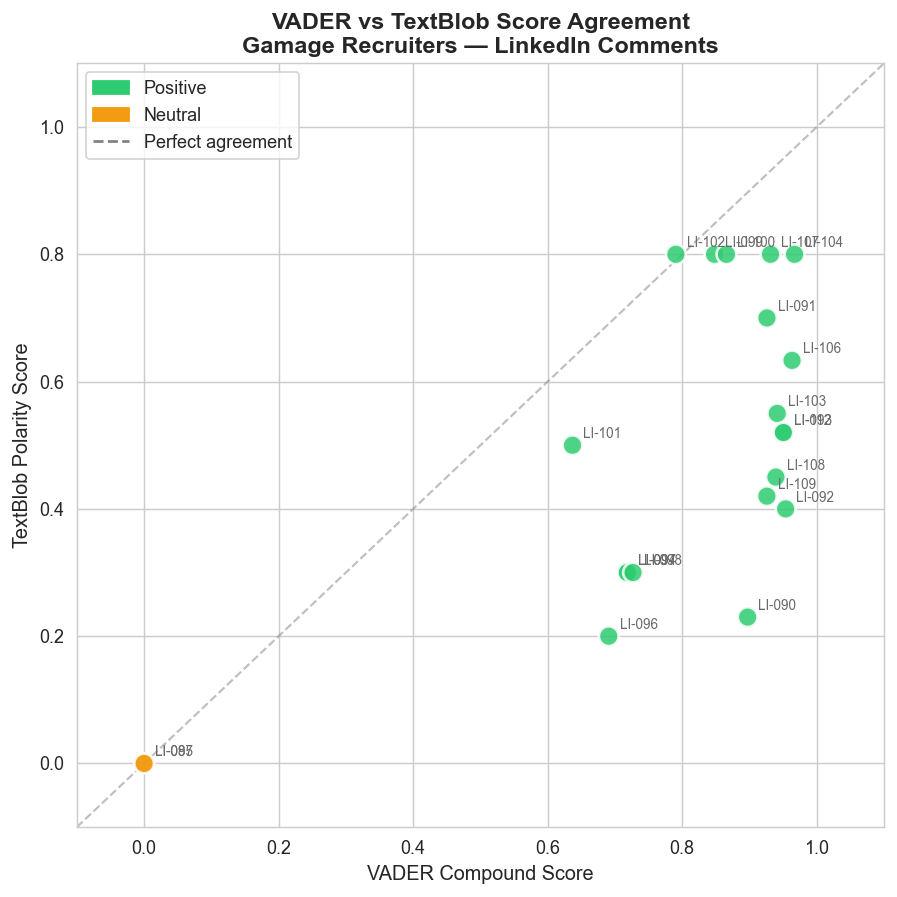

Chart 5 saved: charts/chart5_scatter_vader_vs_textblob.png


In [8]:
fig, ax = plt.subplots(figsize=(7, 7))

scatter_colors = [COLORS[s] for s in df['final_sentiment']]

scatter = ax.scatter(
    df['vader_compound'],
    df['tb_polarity'],
    c         = scatter_colors,
    s         = 120,
    edgecolors= 'white',
    linewidth = 1.5,
    alpha     = 0.85,
    zorder    = 3
)

# Diagonal agreement line
lims = [-0.1, 1.1]
ax.plot(lims, lims, 'gray', linestyle='--',
        linewidth=1.2, alpha=0.5, label='Perfect agreement line')

# Label each point with its ID
for _, row in df.iterrows():
    ax.annotate(
        row['mention_id'],
        (row['vader_compound'], row['tb_polarity']),
        textcoords = 'offset points',
        xytext     = (6, 4),
        fontsize   = 7.5,
        color      = 'dimgray'
    )

# Legend
legend_handles = [
    mpatches.Patch(color=COLORS['Positive'], label='Positive'),
    mpatches.Patch(color=COLORS['Neutral'],  label='Neutral'),
    plt.Line2D([0],[0], color='gray', linestyle='--',
               label='Perfect agreement')
]
ax.legend(handles=legend_handles, fontsize=10)

ax.set_title(
    'VADER vs TextBlob Score Agreement\nGamage Recruiters — LinkedIn Comments',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('VADER Compound Score', fontsize=11)
ax.set_ylabel('TextBlob Polarity Score', fontsize=11)
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.savefig('charts/chart5_scatter_vader_vs_textblob.png', bbox_inches='tight')
plt.show()
print('Chart 5 saved: charts/chart5_scatter_vader_vs_textblob.png')

# **Chart 6: Box Plot — VADER Score Distribution by Post Type**

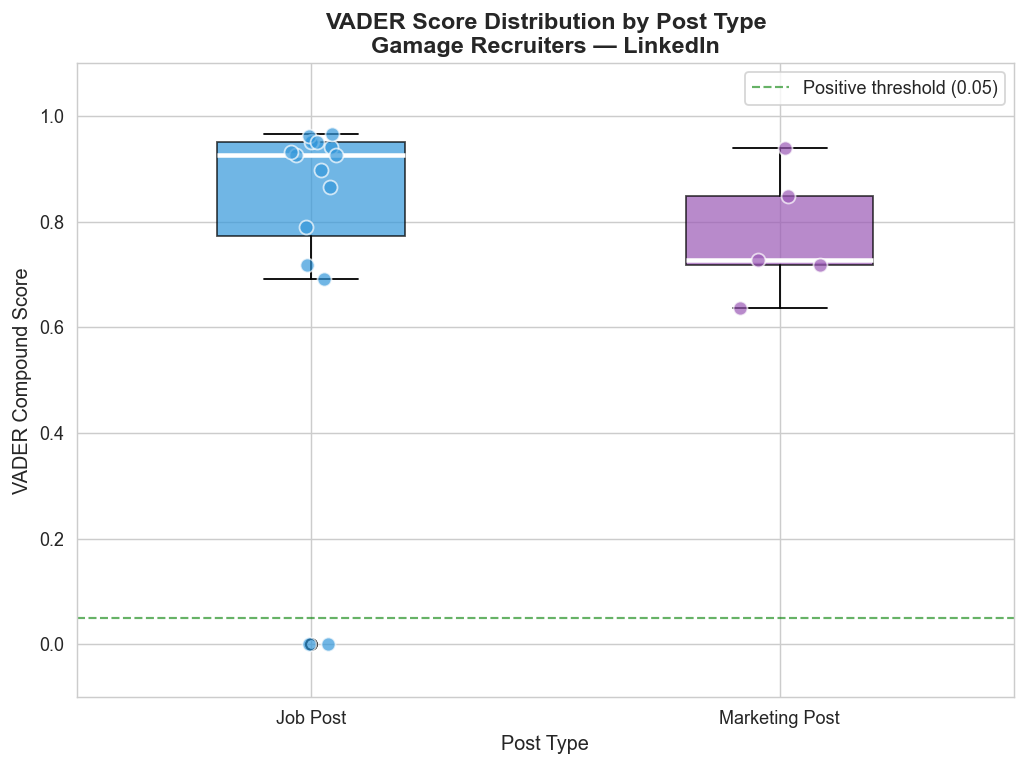

Chart 6 saved: charts/chart6_boxplot_by_posttype.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

post_types    = df['post_type'].unique()
plot_data     = [df[df['post_type'] == pt]['vader_compound'].values
                 for pt in post_types]
box_colors    = ['#3498db', '#9b59b6']

bp = ax.boxplot(
    plot_data,
    labels      = post_types,
    patch_artist= True,
    notch       = False,
    widths      = 0.4
)

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for median in bp['medians']:
    median.set_color('white')
    median.set_linewidth(2.5)

# Overlay actual data points
for i, (pt, color) in enumerate(zip(post_types, box_colors), start=1):
    y = df[df['post_type'] == pt]['vader_compound'].values
    x = np.random.normal(i, 0.04, size=len(y))
    ax.scatter(x, y, alpha=0.7, color=color,
               edgecolors='white', s=60, zorder=3)

ax.axhline(y=0.05, color='green', linestyle='--',
           linewidth=1.2, alpha=0.6, label='Positive threshold (0.05)')

ax.set_title(
    'VADER Score Distribution by Post Type\nGamage Recruiters — LinkedIn',
    fontsize=13, fontweight='bold'
)
ax.set_ylabel('VADER Compound Score', fontsize=11)
ax.set_xlabel('Post Type', fontsize=11)
ax.set_ylim(-0.1, 1.1)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('charts/chart6_boxplot_by_posttype.png', bbox_inches='tight')
plt.show()
print('Chart 6 saved: charts/chart6_boxplot_by_posttype.png')

# **Chart 7: Bar Chart — Average Engagement by Sentiment**

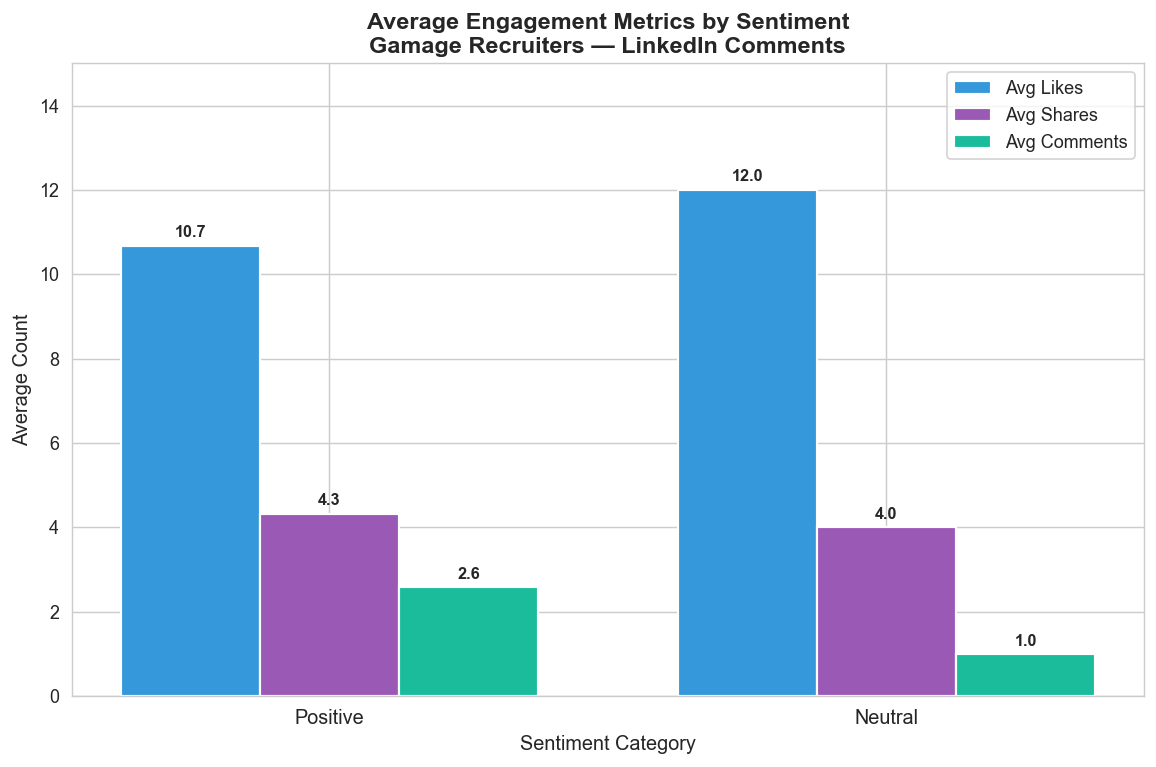

Chart 7 saved: charts/chart7_bar_engagement_by_sentiment.png


In [12]:
engagement = df.groupby('final_sentiment')[
    ['likes', 'shares', 'num_comments']
].mean().round(2)

# Only keep sentiments that exist
engagement = engagement.reindex(['Positive', 'Neutral', 'Negative']).dropna()

x      = range(len(engagement))
width  = 0.25
labels = engagement.index.tolist()
colors_eng = [COLORS[l] for l in labels]

fig, ax = plt.subplots(figsize=(9, 6))

bars1 = ax.bar([i - width     for i in x], engagement['likes'],
               width, label='Avg Likes',
               color='#3498db', edgecolor='white', linewidth=1.2)
bars2 = ax.bar([i             for i in x], engagement['shares'],
               width, label='Avg Shares',
               color='#9b59b6', edgecolor='white', linewidth=1.2)
bars3 = ax.bar([i + width     for i in x], engagement['num_comments'],
               width, label='Avg Comments',
               color='#1abc9c', edgecolor='white', linewidth=1.2)

# Value labels
for bars in [bars1, bars2, bars3]:
    ax.bar_label(bars, fmt='%.1f', fontsize=9,
                 fontweight='bold', padding=3)

ax.set_title(
    'Average Engagement Metrics by Sentiment\nGamage Recruiters — LinkedIn Comments',
    fontsize=13, fontweight='bold'
)
ax.set_ylabel('Average Count', fontsize=11)
ax.set_xlabel('Sentiment Category', fontsize=11)
ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, max(engagement['likes'].max(),
                    engagement['shares'].max(),
                    engagement['num_comments'].max()) * 1.25)

plt.tight_layout()
plt.savefig('charts/chart7_bar_engagement_by_sentiment.png', bbox_inches='tight')
plt.show()
print('Chart 7 saved: charts/chart7_bar_engagement_by_sentiment.png')

# **Save All Charts Summary**

In [13]:
print('=' * 55)
print('STEP 7 COMPLETE — ALL CHARTS SAVED')
print('=' * 55)

charts = [
    ('chart1_pie_overall_sentiment.png',
     'Pie Chart        — Overall sentiment distribution'),
    ('chart2_bar_sentiment_by_posttype.png',
     'Bar Chart        — Sentiment by post type'),
    ('chart3_hbar_vader_scores.png',
     'Horizontal Bar   — VADER score per comment'),
    ('chart4_stacked_quality.png',
     'Stacked Bar      — Meaningful vs low quality'),
    ('chart5_scatter_vader_vs_textblob.png',
     'Scatter Plot     — VADER vs TextBlob agreement'),
    ('chart6_boxplot_by_posttype.png',
     'Box Plot         — Score distribution by post type'),
    ('chart7_bar_engagement_by_sentiment.png',
     'Bar Chart        — Engagement by sentiment'),
]

for filename, description in charts:
    print(f'  ✓  {description}')
    print(f'     Saved as: {filename} in charts folder')
    print()

STEP 7 COMPLETE — ALL CHARTS SAVED
  ✓  Pie Chart        — Overall sentiment distribution
     Saved as: chart1_pie_overall_sentiment.png in charts folder

  ✓  Bar Chart        — Sentiment by post type
     Saved as: chart2_bar_sentiment_by_posttype.png in charts folder

  ✓  Horizontal Bar   — VADER score per comment
     Saved as: chart3_hbar_vader_scores.png in charts folder

  ✓  Stacked Bar      — Meaningful vs low quality
     Saved as: chart4_stacked_quality.png in charts folder

  ✓  Scatter Plot     — VADER vs TextBlob agreement
     Saved as: chart5_scatter_vader_vs_textblob.png in charts folder

  ✓  Box Plot         — Score distribution by post type
     Saved as: chart6_boxplot_by_posttype.png in charts folder

  ✓  Bar Chart        — Engagement by sentiment
     Saved as: chart7_bar_engagement_by_sentiment.png in charts folder

